In [1]:
!pip install pymc arviz pandas numpy scipy matplotlib seaborn
!pip install nutpie numpyro blackjax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.3/252.3 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.9/191.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 81

In [5]:
!pip install PyMC

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 65.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.2
    Uninstalling numpy-2.5.2:
      Successfully uninstalled numpy-2.5.2
  Attempting uninstall: arviz
    Found existing installation: arviz 1.3.0
    Uninstalling arviz-1.3.0:
      Successfully uninstalled arviz-1.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.11.1 requires numpy>=2.1, but you have numpy 2.0.2 which is incompatible.


In [2]:
# ----------------------------------------
# 📊 Simple Bayesian Linear Regression for Media Mix Modeling (No Adstock)
# ----------------------------------------

import pymc as pm
import arviz as az
import pandas as pd
import numpy as np

# ----------------------------------------
# Step 1: Simulate Media Spend and Sales Data
# ----------------------------------------

# Data in lakhs (TV & digital spend, and total sales)
data = {
    "sales":   [100, 120, 130, 125, 150, 160],  # observed weekly sales (lakhs)
    "tv":      [10, 15, 20, 15, 25, 30],        # TV media spend (lakhs)
    "digital": [5, 7, 10, 8, 12, 14]            # Digital media spend (lakhs)
}

df = pd.DataFrame(data)  # Create DataFrame for modeling

In [3]:
# ----------------------------------------
# Step 2: Define PyMC Bayesian Linear Model
# ----------------------------------------

with pm.Model() as model:

    # ---- Priors ----
    # These reflect our beliefs *before* seeing the data
    alpha = pm.Normal("intercept", mu=0, sigma=10)             # Intercept (baseline sales)
    beta_tv = pm.Normal("beta_tv", mu=0.2, sigma=0.1)           # TV channel effectiveness
    beta_digital = pm.Normal("beta_digital", mu=0.3, sigma=0.1) # Digital channel effectiveness
    sigma = pm.HalfNormal("sigma", sigma=10)                   # Standard deviation (uncertainty)

    # ---- Linear Model ----
    # Sales are modeled as a linear combination of TV and digital spend
    mu = alpha + beta_tv * df["tv"] + beta_digital * df["digital"]

    # ---- Likelihood ----
    # Observed sales are normally distributed around expected sales (mu)
    y_obs = pm.Normal("sales", mu=mu, sigma=sigma, observed=df["sales"])


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


array([<Axes: title={'center': 'beta_tv'}>,
       <Axes: title={'center': 'beta_digital'}>], dtype=object)

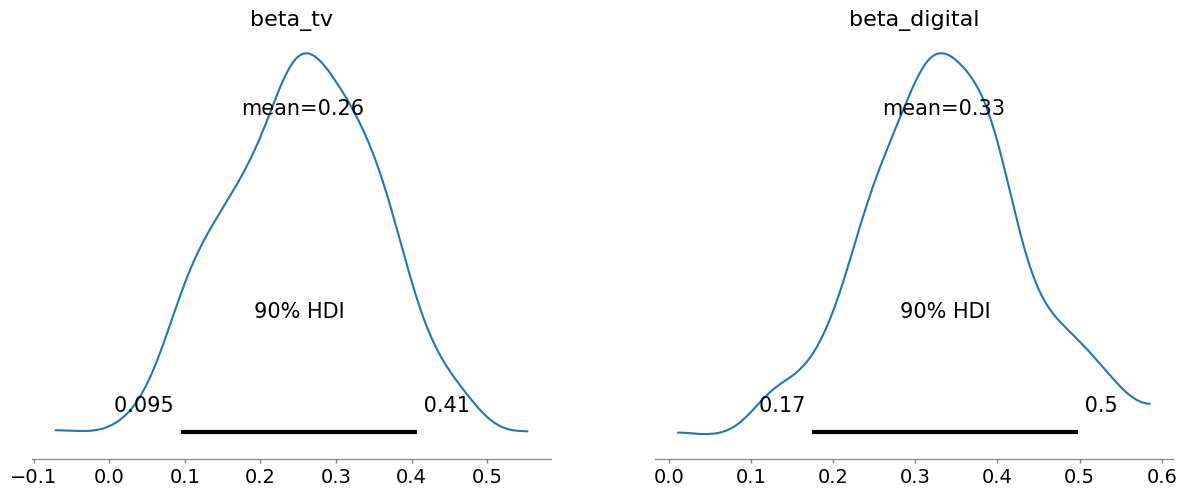

In [4]:
import pymc as pm

# ----------------------------------------
# Step 3: Posterior Inference using MCMC
# ----------------------------------------

with model:
    trace = pm.sample(
        draws=200,
        tune=100,
        target_accept=0.9,
        random_seed=42
    )

# ----------------------------------------
# Step 4: Visualize Posterior Distributions
# ----------------------------------------

# ArviZ provides a clean visual summary of posterior parameter estimates
az.plot_posterior(trace,
                  var_names=["beta_tv", "beta_digital"],
                  hdi_prob=0.9)  # Show 90% highest density intervals (credible intervals)

In [5]:
!git status

fatal: not a git repository (or any of the parent directories): .git
